In [343]:
import numpy as np

import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model

import matplotlib
import matplotlib.pyplot as plt


In [344]:
# Independent data
nsamp = 100
xdat = np.random.uniform(-1,5,nsamp)

# Data:
beta = np.array([4.342, -0.7, 2.7])
y0 = beta[0] + beta[1] * np.exp(-xdat/2) + beta[2] * np.exp(-xdat)
wstd = 0 # noise
ydat = y0 + np.random.normal(0,wstd,nsamp)

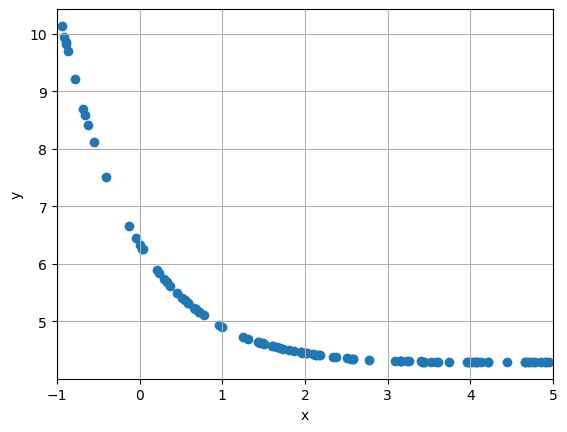

In [345]:
plt.scatter(xdat,ydat)
plt.xlim([-1,5])
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

In [346]:
# Split
utr, uts, ytr, yts = train_test_split(xdat, ydat, test_size=0.5)

In [347]:
utr.shape

(50,)

In [348]:
ytr.shape

(50,)

## using sklearn:

In [349]:
# Fit:
MSE = []
dtest = np.arange(1,12)

for d in dtest:
    # model using train data:
    Xtr = np.exp(utr[:, None] * np.arange(1, d+1)/(-d))
    model = linear_model.LinearRegression()
    model.fit(Xtr, ytr)

    # predict with test data:
    Xts = np.exp(uts[:, None] * np.arange(1, d+1)/(-d))
    yhat = model.predict(Xts)

    # find mse:
    MSE.append(np.mean((yhat - yts)**2))

    print("intercept for d = {0:2d} is {1:f}".format(d, model.intercept_), " coefficients: ", *model.coef_)

print(MSE)

intercept for d =  1 is 4.174728  coefficients:  2.284629023018996
intercept for d =  2 is 4.342000  coefficients:  -0.6999999999999986 2.7000000000000006
intercept for d =  3 is 4.360384  coefficients:  -0.30517545084373254 -0.4922411780739323 2.778508495518083
intercept for d =  4 is 4.342000  coefficients:  -8.10459339113168e-15 -0.6999999999999809 -2.1881569693641322e-14 2.7000000000000086
intercept for d =  5 is 4.338678  coefficients:  0.04080701688573555 -0.3483352782516785 -0.47895800870543886 0.10629157531842985 2.683515047074661
intercept for d =  6 is 4.342000  coefficients:  -8.340503152357289e-13 3.3591849708062943e-12 -0.700000000006973 7.883661796417617e-12 -4.617260998693284e-12 2.7000000000010975
intercept for d =  7 is 4.342674  coefficients:  -0.008747221284644408 0.05723535980103098 -0.36993943880137575 -0.47247276754511924 0.11926230241298427 -0.029757662858377654 2.7037457738310646
intercept for d =  8 is 4.342000  coefficients:  6.045666720186957e-10 -2.722448385

## using linalg:

In [350]:
MSE_np = []
for d_np in dtest:
    # model:
    Xtr = np.exp(utr[:, None] * np.arange(d_np+1)/(-d_np))
    out = np.linalg.lstsq(Xtr, ytr, rcond=None)

    # predict:
    Xts = np.exp(uts[:, None] * np.arange(d_np+1)/(-d_np))
    yhat = Xts @ out[0]

    MSE_np.append(np.mean((yhat - yts)**2))

    print("intercept for d = {0:2d} is {1:f}".format(d_np, out[0][0]), " coefficients: ", *out[0][1:] )

print(MSE_np)


intercept for d =  1 is 4.174728  coefficients:  2.284629023018995
intercept for d =  2 is 4.342000  coefficients:  -0.7000000000000018 2.7000000000000015
intercept for d =  3 is 4.360384  coefficients:  -0.3051754508437424 -0.49224117807392553 2.7785084955180768
intercept for d =  4 is 4.342000  coefficients:  -3.7969627442180354e-14 -0.6999999999998984 -1.103199132017421e-13 2.700000000000043
intercept for d =  5 is 4.338678  coefficients:  0.04080701688614252 -0.34833527825290794 -0.47895800870367966 0.10629157531722902 2.6835150470749762
intercept for d =  6 is 4.342000  coefficients:  -3.784639268644696e-12 1.396492153765597e-11 -0.7000000000268091 2.8280493085601127e-11 -1.5551297880847628e-11 2.700000000003487
intercept for d =  7 is 4.342674  coefficients:  -0.00874722142687534 0.057235360368668234 -0.36993944004066315 -0.4724727659468486 0.1192623011953587 -0.029757662350919433 2.703745773741794
intercept for d =  8 is 4.342000  coefficients:  3.273199489228773e-10 -1.52332891

## Compare:

In [351]:
np.sum((np.array(MSE) - np.array(MSE_np))**2)

np.float64(1.529373939292154e-33)

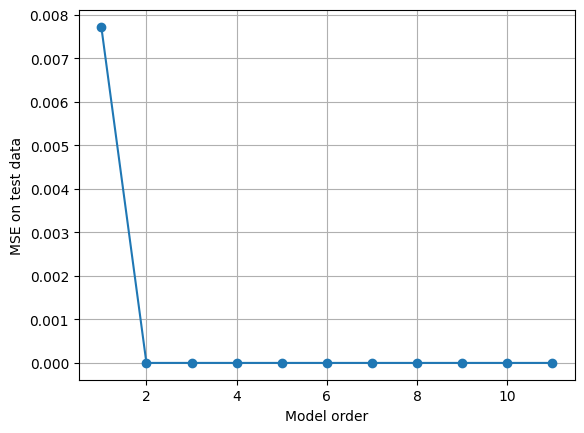

In [352]:
plt.plot(dtest, MSE, 'o-')
plt.xlabel('Model order')
plt.ylabel('MSE on test data')
plt.grid()

In [353]:
print(MSE.index(min(MSE)) + 1)

4


## Matrix multiplication check:

In [354]:
A = np.arange(-5,6,2).reshape(2,3)
b = np.array([[2],[-9],[7]]).reshape(3,)
print(A)
print(b)

[[-5 -3 -1]
 [ 1  3  5]]
[ 2 -9  7]


In [355]:
A@b

array([10, 10])